In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce
import scipy.stats as stats

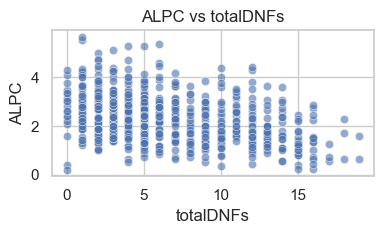

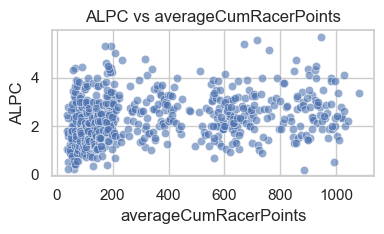

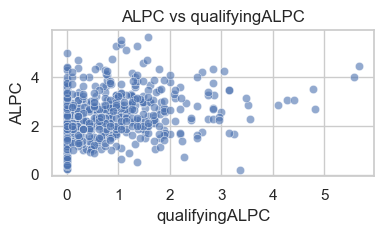

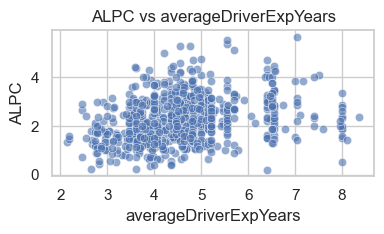

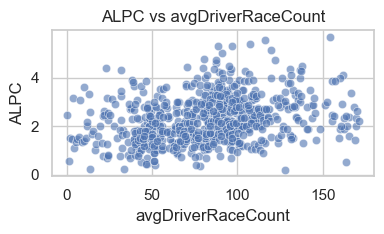

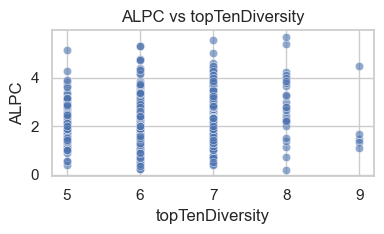

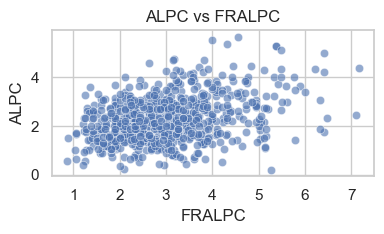

In [66]:
# Load your data
df = pd.read_csv(r"..\Patrick\race_predictor_data.csv")

# Exclude these columns
exclude_cols = ['raceId', 'circuitId', 'ALPC', 'countryId']

# Get the list of predictors
predictors = [col for col in df.columns if col not in exclude_cols]

# Set up the plot style
sns.set(style="whitegrid")

# Create a scatter plot for each predictor against ALPC
for col in predictors:
    plt.figure(figsize=(4, 2.5))
    sns.scatterplot(data=df, x=col, y='ALPC', alpha=0.6)
    plt.title(f'ALPC vs {col}')
    plt.xlabel(col)
    plt.ylabel('ALPC')
    plt.tight_layout()
    plt.show()

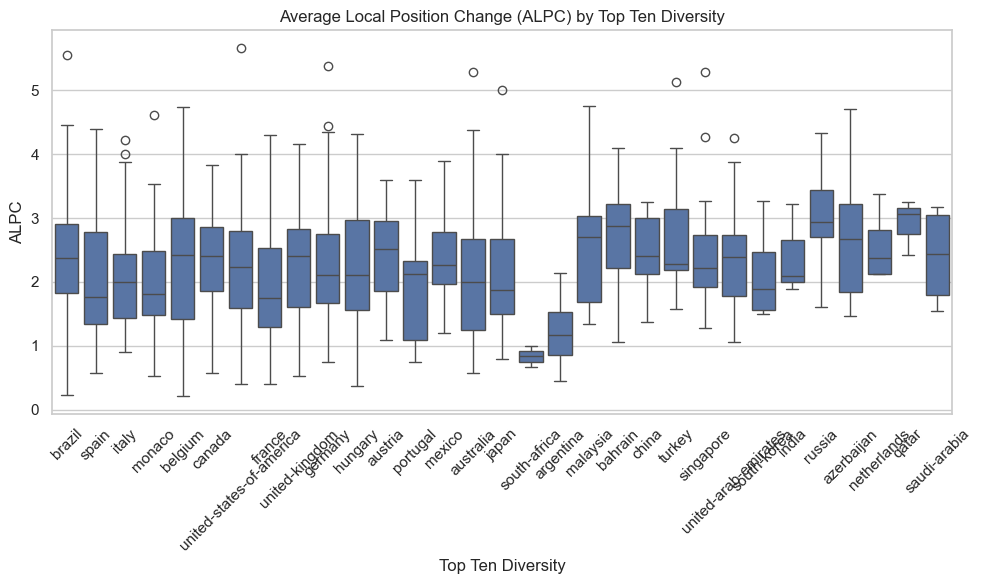

In [48]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='countryId', y='ALPC', data=df)
plt.title('Average Local Position Change (ALPC) by Top Ten Diversity')
plt.xlabel('Top Ten Diversity')
plt.ylabel('ALPC')
plt.xticks(rotation=45)  # Optional, for better readability
plt.tight_layout()
plt.show()

In [69]:
df[['ALPC', 'totalDNFs', 'averageCumRacerPoints', 'qualifyingALPC', 'averageDriverExpYears',
    'avgDriverRaceCount', 'FRALPC']].corr(method='pearson')

,ALPC,totalDNFs,averageCumRacerPoints,qualifyingALPC,averageDriverExpYears,avgDriverRaceCount,FRALPC
ALPC,1.000000,-0.376210,0.263737,0.317361,0.273767,0.288047,0.360120
totalDNFs,-0.376210,1.000000,-0.670310,-0.459697,-0.569350,-0.784019,-0.071045
averageCumRacerPoints,0.263737,-0.670310,1.000000,0.423809,0.874937,0.881892,0.112673
qualifyingALPC,0.317361,-0.459697,0.423809,1.000000,0.373818,0.460799,0.307816
averageDriverExpYears,0.273767,-0.569350,0.874937,0.373818,1.000000,0.829157,0.214860
avgDriverRaceCount,0.288047,-0.784019,0.881892,0.460799,0.829157,1.000000,0.147243
FRALPC,0.360120,-0.071045,0.112673,0.307816,0.214860,0.147243,1.000000


In [70]:
df[['ALPC', 'totalDNFs', 'averageCumRacerPoints', 'qualifyingALPC', 'averageDriverExpYears',
    'avgDriverRaceCount', 'FRALPC']].corr(method='spearman')

,ALPC,totalDNFs,averageCumRacerPoints,qualifyingALPC,averageDriverExpYears,avgDriverRaceCount,FRALPC
ALPC,1.000000,-0.380102,0.329300,0.372169,0.305487,0.312526,0.320389
totalDNFs,-0.380102,1.000000,-0.806355,-0.621929,-0.631664,-0.806990,-0.073131
averageCumRacerPoints,0.329300,-0.806355,1.000000,0.668774,0.839014,0.960429,0.098490
qualifyingALPC,0.372169,-0.621929,0.668774,1.000000,0.578150,0.667747,0.260784
averageDriverExpYears,0.305487,-0.631664,0.839014,0.578150,1.000000,0.836166,0.173915
avgDriverRaceCount,0.312526,-0.806990,0.960429,0.667747,0.836166,1.000000,0.096800
FRALPC,0.320389,-0.073131,0.098490,0.260784,0.173915,0.096800,1.000000


In [71]:
df[['ALPC', 'totalDNFs', 'averageCumRacerPoints', 'qualifyingALPC', 'averageDriverExpYears',
    'avgDriverRaceCount', 'FRALPC']].corr(method='kendall')

,ALPC,totalDNFs,averageCumRacerPoints,qualifyingALPC,averageDriverExpYears,avgDriverRaceCount,FRALPC
ALPC,1.000000,-0.269228,0.222835,0.271456,0.204958,0.211741,0.218415
totalDNFs,-0.269228,1.000000,-0.617154,-0.460742,-0.452283,-0.620578,-0.049094
averageCumRacerPoints,0.222835,-0.617154,1.000000,0.475386,0.672742,0.834945,0.066097
qualifyingALPC,0.271456,-0.460742,0.475386,1.000000,0.408589,0.477365,0.186552
averageDriverExpYears,0.204958,-0.452283,0.672742,0.408589,1.000000,0.671168,0.118819
avgDriverRaceCount,0.211741,-0.620578,0.834945,0.477365,0.671168,1.000000,0.064762
FRALPC,0.218415,-0.049094,0.066097,0.186552,0.118819,0.064762,1.000000


In [50]:
categories = df['countryId'].unique()
groups = [df[df['countryId'] == cat]['ALPC'] for cat in categories]
f_stat, p_val = stats.f_oneway(*groups)

print("ANOVA F-statistic:", f_stat)
print("p-value:", p_val)

ANOVA F-statistic: 1.52300293769961
p-value: 0.037638865175648045


In [51]:
# Assuming your DataFrame is named `df` and has 'ALPC' and 'circuitId' columns
categories = df['countryId'].unique()
groups = [df[df['countryId'] == cat]['ALPC'] for cat in categories]

# Run ANOVA
f_stat, p_val = stats.f_oneway(*groups)

# Compute sum of squares between groups
grand_mean = df['ALPC'].mean()
ss_between = sum([len(group) * (group.mean() - grand_mean)**2 for group in groups])

# Compute total sum of squares
ss_total = sum((df['ALPC'] - grand_mean)**2)

# Eta squared
eta_squared = ss_between / ss_total
print("Eta Squared (η²):", eta_squared)

Eta Squared (η²): 0.06348578212275229


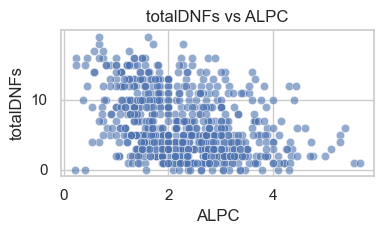

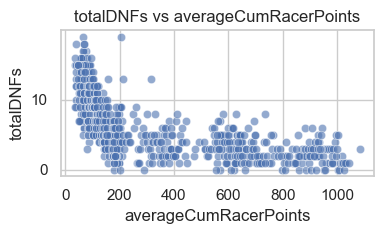

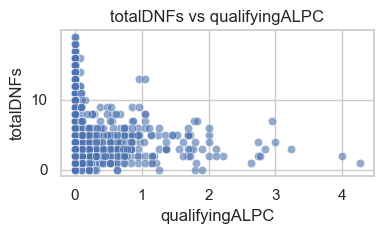

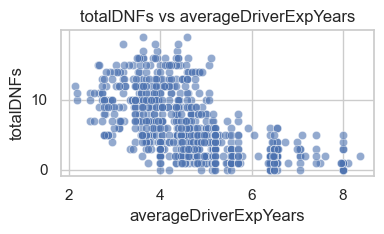

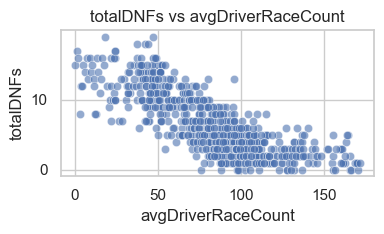

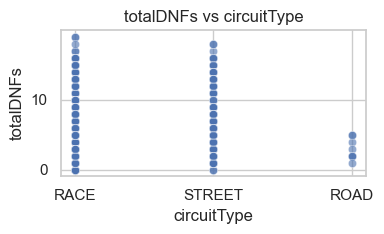

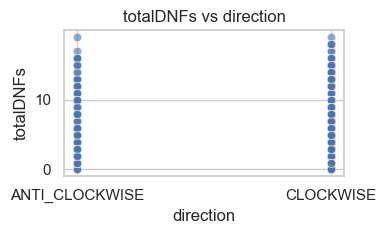

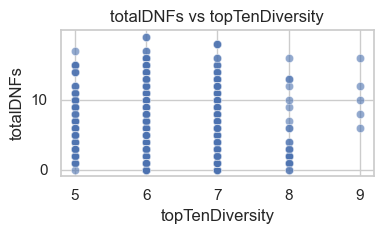

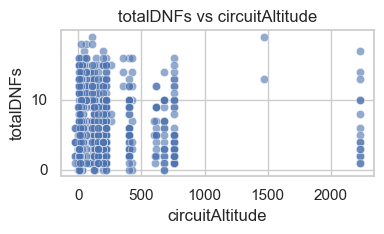

In [58]:
# Load your data
df = pd.read_csv("race_predictor_data.csv")

# Columns to exclude from x-axis
exclude_cols = ['raceId', 'circuitId', 'totalDNFs', 'countryId']

# Get list of predictor columns to plot against totalDNFs
predictors = [col for col in df.columns if col not in exclude_cols]

# Set plot style
sns.set(style="whitegrid")

# Generate scatter plots
for col in predictors:
    plt.figure(figsize=(4, 2.5))
    sns.scatterplot(data=df, x=col, y='totalDNFs', alpha=0.6)
    plt.title(f'totalDNFs vs {col}')
    plt.xlabel(col)
    plt.ylabel('totalDNFs')
    plt.tight_layout()
    plt.show()

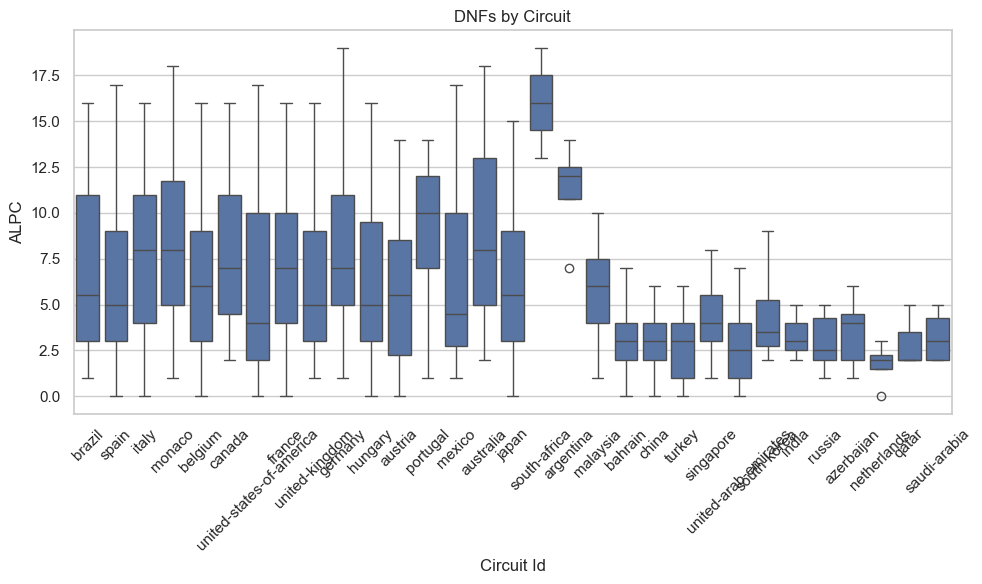

In [54]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='countryId', y='totalDNFs', data=df)
plt.title('DNFs by Circuit')
plt.xlabel('Circuit Id')
plt.ylabel('ALPC')
plt.xticks(rotation=45)  # Optional, for better readability
plt.tight_layout()
plt.show()

In [55]:
#df[['ALPC', 'totalDNFs', 'averageCumRacerPoints', 'qualifyingALPC', 'averageDriverExpYears', 'avgDriverRaceCount']].corr(method='pearson')

categories = df['countryId'].unique()
groups = [df[df['countryId'] == cat]['totalDNFs'] for cat in categories]
f_stat, p_val = stats.f_oneway(*groups)

print("ANOVA F-statistic:", f_stat)
print("p-value:", p_val)

ANOVA F-statistic: 4.215860892494897
p-value: 1.9813247453103664e-12


In [56]:
# Assuming your DataFrame is named `df` and has 'ALPC' and 'circuitId' columns
categories = df['countryId'].unique()
groups = [df[df['countryId'] == cat]['totalDNFs'] for cat in categories]

# Run ANOVA
f_stat, p_val = stats.f_oneway(*groups)

# Compute sum of squares between groups
grand_mean = df['totalDNFs'].mean()
ss_between = sum([len(group) * (group.mean() - grand_mean)**2 for group in groups])

# Compute total sum of squares
ss_total = sum((df['totalDNFs'] - grand_mean)**2)

# Eta squared
eta_squared = ss_between / ss_total
print("Eta Squared (η²):", eta_squared)

Eta Squared (η²): 0.1580008072004169
